# Air-training analysis: full air-cycle organization

The goal of this analysis is to determine how air delivery structures locomotor behavior across the full air-on and air-off cycle.

Rather than using post-pre delta values as the dependent variable, we model actual locomotor values from sequential windows. This allows us to compare biologically meaningful epochs directly while preserving absolute locomotor levels.

The main air-cycle sequence is:

pre_air_on → post_air_on → pre_air_on_mid → post_air_on_mid → pre_air_off → post_air_off → pre_air_off_mid → post_air_off_mid → pre_air_on_next

Planned comparisons:

1. Air-onset transition:
   pre_air_on vs post_air_on

2. Early air-on progression:
   post_air_on vs pre_air_on_mid

3. Late air-on progression:
   post_air_on_mid vs pre_air_off

4. Air-offset transition:
   pre_air_off vs post_air_off

5. Early air-off recovery:
   post_air_off vs pre_air_off_mid

6. Late air-off recovery / return toward next baseline:
   post_air_off_mid vs pre_air_on_next

Outcomes are analyzed in the following order:
1. fraction moving
2. fraction forward
3. path speed and net speed
4. path distance and net distance

For each outcome and planned comparison, linear mixed-effects models are used. Basic models test whether the second epoch differs from the first. Time-dependent models test whether this difference changes across air-training sessions and within-session time.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Find the project root that contains the src folder
current = Path.cwd().resolve()

for p in [current] + list(current.parents):
    if (p / "src").exists():
        repo_root = p
        break
else:
    raise FileNotFoundError("Could not find a folder containing 'src'.")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Current working directory:", current)
print("Added repo root:", repo_root)
print("src exists:", (repo_root / "src").exists())

from pathlib import Path
import numpy as np
import pandas as pd

import src.utils.pdata_io as pdio
from src.proc.extract_epoch_windows import load_epoch_windows

data_root, pdata_root, cc_data = pdio.load_project_context()

windows_df = load_epoch_windows(
    pdata_root=pdata_root,
    filename="behavior_epoch_windows.h5",
    key="windows/prepost_1s"
)

valid_windows = windows_df[windows_df["valid_window"]].copy()

print("All windows:", windows_df.shape)
print("Valid windows:", valid_windows.shape)

valid_windows.groupby(["phase", "epoch_name"]).size().reset_index(name="n_windows")

encoder_epoch_df = pd.read_hdf(
    Path(pdata_root) / "_cache" / "behavior_epoch_metrics.h5",
    key="encoder/prepost_1s_speedThresh_1cms"
)

from src.qc.qc_events import load_behavior_qc_tables

events_df, session_summary_df = load_behavior_qc_tables(
    pdata_root=pdata_root,
    filename="behavior_QC.h5"
)

from src.utils.pdata_organize import make_session_availability_summary

session_availability_df = make_session_availability_summary(
    events_df=events_df,
    windows_df=windows_df,
    min_session_duration_s=900,
    min_valid_events=3,
)

from src.utils.pdata_organize import add_day_bins_to_sessions

session_day_df = add_day_bins_to_sessions(
    session_availability_df,
    use_good_sessions_only=True,
)

Current working directory: /home/nmldata2/ccaw/Python/notebooks
Added repo root: /home/nmldata2/ccaw/Python
src exists: True
/home/nmldata2/ccaw/Python
[LOADED] Project context: /mnt/pdata/Classical_Conditioning/_cache/project_context.pkl
[LOADED] Epoch windows: /mnt/pdata/Classical_Conditioning/_cache/behavior_epoch_windows.h5
[KEY] windows/prepost_1s
All windows: (103980, 40)
Valid windows: (101861, 40)
[LOADED] Behavior QC tables: /mnt/pdata/Classical_Conditioning/_cache/behavior_QC.h5


In [2]:
import numpy as np
import pandas as pd

# --------------------------------------------------
# Primary outcomes for manuscript
# --------------------------------------------------

PRIMARY_OUTCOMES = [
    "frac_moving",
    "frac_forward",
    "mean_speed_path_cms",
]

OUTCOME_LABELS = {
    "frac_moving": "Fraction moving",
    "frac_forward": "Fraction forward",
    "mean_speed_path_cms": "Speed (cm/s)",
}

# --------------------------------------------------
# Start from epoch-level dataframe
# --------------------------------------------------

df0 = encoder_epoch_df.copy()

print("Available phases:")
display(df0["phase"].value_counts())

# --------------------------------------------------
# Select air-training phase
# --------------------------------------------------

phase_vals = df0["phase"].dropna().astype(str).unique().tolist()

if "air_training" in phase_vals:
    air_phase = "air_training"
elif "air-training" in phase_vals:
    air_phase = "air-training"
else:
    air_candidates = [p for p in phase_vals if "air" in p.lower() and "tone" not in p.lower()]
    if len(air_candidates) == 0:
        raise ValueError(f"Could not identify air-training phase. Available phases: {phase_vals}")
    air_phase = air_candidates[0]

print("Using air-training phase:", air_phase)

air_cycle_df = df0[df0["phase"].astype(str) == air_phase].copy()

# --------------------------------------------------
# Keep valid windows only
# --------------------------------------------------

if "valid_window" in air_cycle_df.columns:
    air_cycle_df = air_cycle_df[air_cycle_df["valid_window"] == True].copy()

if "good_session_basic" in air_cycle_df.columns:
    air_cycle_df = air_cycle_df[air_cycle_df["good_session_basic"] == True].copy()

# --------------------------------------------------
# Check epoch names
# --------------------------------------------------

print("Available epoch names:")
display(
    air_cycle_df["epoch_name"]
    .value_counts()
    .reset_index()
    .rename(columns={"index": "epoch_name", "epoch_name": "n"})
)

Available phases:


phase
air_training         42362
habituation          38237
tone_air_training    21262
Name: count, dtype: int64

Using air-training phase: air_training
Available epoch names:


,n,count
0,air_off_pre_1s,3535
1,air_on_mid_post_1s,3535
2,air_on_post_1s,3535
3,pseudo_tone_off_post_1s,3535
4,pseudo_tone_off_pre_1s,3535
5,air_on_mid_pre_1s,3534
6,air_on_pre_1s,3532
7,pseudo_tone_on_post_1s,3532
8,pseudo_tone_on_pre_1s,3531
9,air_off_post_1s,3525


In [3]:
# --------------------------------------------------
# Diagnose available air-training epoch names
# --------------------------------------------------

print("Available phases:")
display(encoder_epoch_df["phase"].value_counts(dropna=False))

df0 = encoder_epoch_df.copy()

# Use the same phase selection as before
phase_vals = df0["phase"].dropna().astype(str).unique().tolist()

if "air_training" in phase_vals:
    air_phase = "air_training"
elif "air-training" in phase_vals:
    air_phase = "air-training"
else:
    air_candidates = [
        p for p in phase_vals
        if "air" in p.lower() and "tone" not in p.lower()
    ]
    air_phase = air_candidates[0]

print("Using air phase:", air_phase)

air_cycle_df = df0[df0["phase"].astype(str) == air_phase].copy()

if "valid_window" in air_cycle_df.columns:
    air_cycle_df = air_cycle_df[air_cycle_df["valid_window"] == True].copy()

if "good_session_basic" in air_cycle_df.columns:
    air_cycle_df = air_cycle_df[air_cycle_df["good_session_basic"] == True].copy()

print("\nAvailable epoch names:")
available_epochs = sorted(air_cycle_df["epoch_name"].dropna().astype(str).unique())
for e in available_epochs:
    print(e)

print("\nCounts by epoch:")
display(
    air_cycle_df
    .groupby("epoch_name", observed=True)
    .size()
    .reset_index(name="n")
    .sort_values("epoch_name")
)

Available phases:


phase
air_training         42362
habituation          38237
tone_air_training    21262
Name: count, dtype: int64

Using air phase: air_training

Available epoch names:
air_off_mid_post_1s
air_off_mid_pre_1s
air_off_post_1s
air_off_pre_1s
air_on_mid_post_1s
air_on_mid_pre_1s
air_on_post_1s
air_on_pre_1s
pseudo_tone_off_post_1s
pseudo_tone_off_pre_1s
pseudo_tone_on_post_1s
pseudo_tone_on_pre_1s

Counts by epoch:


,epoch_name,n
0,air_off_mid_post_1s,3516
1,air_off_mid_pre_1s,3517
2,air_off_post_1s,3525
3,air_off_pre_1s,3535
4,air_on_mid_post_1s,3535
5,air_on_mid_pre_1s,3534
6,air_on_post_1s,3535
7,air_on_pre_1s,3532
8,pseudo_tone_off_post_1s,3535
9,pseudo_tone_off_pre_1s,3535


In [4]:
# --------------------------------------------------
# Ordered epoch sequence for air-cycle analysis
# Based on actual epoch names in encoder_epoch_df
# --------------------------------------------------

AIR_EPOCH_ORDER = [
    "air_on_pre_1s",
    "air_on_post_1s",
    "air_on_mid_pre_1s",
    "air_on_mid_post_1s",
    "air_off_pre_1s",
    "air_off_post_1s",
    "air_off_mid_pre_1s",
    "air_off_mid_post_1s",
]

# These are pseudo-tone timing anchors.
# They are useful for the tone-vs-pseudo-tone analysis,
# but not for the main air-on/air-off cycle analysis.
PSEUDO_TONE_EPOCHS = [
    "pseudo_tone_on_pre_1s",
    "pseudo_tone_on_post_1s",
    "pseudo_tone_off_pre_1s",
    "pseudo_tone_off_post_1s",
]

available_epochs = sorted(air_cycle_df["epoch_name"].dropna().astype(str).unique())

print("Available epoch names:")
for e in available_epochs:
    print(e)

missing_epochs = [e for e in AIR_EPOCH_ORDER if e not in available_epochs]
extra_epochs = [e for e in available_epochs if e not in AIR_EPOCH_ORDER]

print("\nMissing expected air-cycle epochs:")
print(missing_epochs)

print("\nExtra epochs not used in this air-cycle analysis:")
print(extra_epochs)

if len(missing_epochs) > 0:
    raise ValueError("Some expected air-cycle epochs are missing. Update AIR_EPOCH_ORDER.")

# Keep only the 8 air-cycle epochs
air_cycle_df = air_cycle_df[
    air_cycle_df["epoch_name"].isin(AIR_EPOCH_ORDER)
].copy()

air_cycle_df["epoch_name"] = pd.Categorical(
    air_cycle_df["epoch_name"],
    categories=AIR_EPOCH_ORDER,
    ordered=True,
)

# QC
display(
    air_cycle_df
    .groupby("epoch_name", observed=True)
    .size()
    .reset_index(name="n")
)

Available epoch names:
air_off_mid_post_1s
air_off_mid_pre_1s
air_off_post_1s
air_off_pre_1s
air_on_mid_post_1s
air_on_mid_pre_1s
air_on_post_1s
air_on_pre_1s
pseudo_tone_off_post_1s
pseudo_tone_off_pre_1s
pseudo_tone_on_post_1s
pseudo_tone_on_pre_1s

Missing expected air-cycle epochs:
[]

Extra epochs not used in this air-cycle analysis:
['pseudo_tone_off_post_1s', 'pseudo_tone_off_pre_1s', 'pseudo_tone_on_post_1s', 'pseudo_tone_on_pre_1s']


,epoch_name,n
0,air_on_pre_1s,3532
1,air_on_post_1s,3535
2,air_on_mid_pre_1s,3534
3,air_on_mid_post_1s,3535
4,air_off_pre_1s,3535
5,air_off_post_1s,3525
6,air_off_mid_pre_1s,3517
7,air_off_mid_post_1s,3516


In [5]:
# --------------------------------------------------
# QC: check columns currently in air_cycle_df
# --------------------------------------------------

print("air_cycle_df shape:", air_cycle_df.shape)
print("Columns:")
print(air_cycle_df.columns.tolist())

print("\nColumns related to animal/session/date:")
print([c for c in air_cycle_df.columns if any(k in c.lower() for k in ["animal", "date", "session", "day"])])

print("\nColumns related to trial/cycle/event/anchor:")
print([c for c in air_cycle_df.columns if any(k in c.lower() for k in ["trial", "cycle", "event", "anchor"])])

print("\nEpoch counts:")
display(
    air_cycle_df
    .groupby("epoch_name", observed=True)
    .size()
    .reset_index(name="n")
)

air_cycle_df shape: (42362, 59)
Columns:
['animal', 'date', 'phase', 'event_number', 'anchor_name', 'anchor_type', 'anchor_time_s', 'window_position', 'window_s', 'epoch_name', 'window_start_s', 'window_end_s', 'start_idx', 'end_idx', 'on_time_s', 'off_time_s', 'next_on_time_s', 'on_duration_s', 'off_duration_s', 'session_duration_s', 'session_time_bin', 'parent_event_valid', 'valid_window_basic', 'valid_window', 'overlap_flag', 'overlap_s', 'overlap_with', 'anchor_warning', 'invalid_reason', 'good_session_basic', 'rig_day_from_date', 'rig_session_number', 'phase_day_from_date', 'phase_session_number', 'rig_session_start_min', 'phase_session_start_min', 'recording_duration_min', 'anchor_session_time_min', 'anchor_rig_time_min', 'anchor_phase_time_min', 'speed_thresh_cms', 'fs', 'n_samples_window', 'mean_speed_path_cms', 'median_speed_path_cms', 'peak_speed_path_cms', 'mean_speed_net_cms', 'median_speed_net_cms', 'min_speed_net_cms', 'max_speed_net_cms', 'distance_path_cm', 'distance_ne

,epoch_name,n
0,air_off_mid_post_1s,3516
1,air_off_mid_pre_1s,3517
2,air_off_post_1s,3525
3,air_off_pre_1s,3535
4,air_on_mid_post_1s,3535
5,air_on_mid_pre_1s,3534
6,air_on_post_1s,3535
7,air_on_pre_1s,3532
8,pseudo_tone_off_post_1s,3535
9,pseudo_tone_off_pre_1s,3535


In [6]:
# --------------------------------------------------
# Finalize air_cycle_df IDs and predictors before R
# --------------------------------------------------

air_cycle_df = air_cycle_df.copy()

# --------------------------------------------------
# Animal-day/session ID
# --------------------------------------------------

if "animal_day" not in air_cycle_df.columns:
    if "animal" in air_cycle_df.columns and "date" in air_cycle_df.columns:
        air_cycle_df["animal_day"] = (
            air_cycle_df["animal"].astype(str) + ":" +
            air_cycle_df["date"].astype(str)
        )
    elif "animal" in air_cycle_df.columns and "session" in air_cycle_df.columns:
        air_cycle_df["animal_day"] = (
            air_cycle_df["animal"].astype(str) + ":" +
            air_cycle_df["session"].astype(str)
        )
    else:
        raise ValueError(
            "Could not create animal_day. Need animal + date or animal + session columns."
        )

# --------------------------------------------------
# Air-cycle identity
# --------------------------------------------------
# We need one ID for each air cycle/trial, repeated across the 8 epoch windows.
# Try likely columns first.

cycle_col_candidates = [
    "air_cycle_id",
    "cycle_id",
    "trial_id",
    "trial_number",
    "trial",
    "event_id",
    "event_number",
    "anchor_event_id",
    "anchor_id",
]

cycle_col = None
for c in cycle_col_candidates:
    if c in air_cycle_df.columns and c != "air_cycle_id":
        cycle_col = c
        break

if "air_cycle_id" in air_cycle_df.columns:
    print("air_cycle_id already exists.")
else:
    if cycle_col is None:
        print("Available trial/cycle/event/anchor columns:")
        print([c for c in air_cycle_df.columns if any(k in c.lower() for k in ["trial", "cycle", "event", "anchor"])])

        raise ValueError(
            "Could not find trial/cycle/event column for air_cycle_id. "
            "Inspect the printed columns and choose the correct one."
        )

    print("Using cycle column:", cycle_col)

    air_cycle_df["air_cycle_id"] = (
        air_cycle_df["animal_day"].astype(str) + ":cycle_" +
        air_cycle_df[cycle_col].astype(str)
    )

# --------------------------------------------------
# Phase session number
# --------------------------------------------------

if "phase_session" not in air_cycle_df.columns:
    if "phase_session_number" in air_cycle_df.columns:
        air_cycle_df["phase_session"] = air_cycle_df["phase_session_number"]
    elif "phase_day_number_good" in air_cycle_df.columns:
        air_cycle_df["phase_session"] = air_cycle_df["phase_day_number_good"]
    elif "phase_day" in air_cycle_df.columns:
        air_cycle_df["phase_session"] = air_cycle_df["phase_day"]
    else:
        print("Available session/day columns:")
        print([c for c in air_cycle_df.columns if "session" in c.lower() or "day" in c.lower()])
        raise ValueError("Could not find phase session/day column.")

air_cycle_df["phase_session"] = air_cycle_df["phase_session"].astype(float)

air_cycle_df["phase_session_c"] = (
    air_cycle_df["phase_session"] -
    air_cycle_df["phase_session"].mean()
)

# --------------------------------------------------
# Within-session time
# --------------------------------------------------

if "session_time_min" not in air_cycle_df.columns:
    if "anchor_session_time_min" in air_cycle_df.columns:
        air_cycle_df["session_time_min"] = air_cycle_df["anchor_session_time_min"]
    elif "window_center_time_s" in air_cycle_df.columns:
        air_cycle_df["session_time_min"] = air_cycle_df["window_center_time_s"] / 60.0
    elif "anchor_time_s" in air_cycle_df.columns:
        air_cycle_df["session_time_min"] = air_cycle_df["anchor_time_s"] / 60.0
    elif "session_time_s" in air_cycle_df.columns:
        air_cycle_df["session_time_min"] = air_cycle_df["session_time_s"] / 60.0
    else:
        print("Available time columns:")
        print([c for c in air_cycle_df.columns if "time" in c.lower()])
        raise ValueError("Could not find session-time column.")

air_cycle_df["session_time_10m_c"] = (
    air_cycle_df["session_time_min"] -
    air_cycle_df["session_time_min"].mean()
) / 10.0

# --------------------------------------------------
# Keep only needed columns for final air-cycle analysis
# --------------------------------------------------

PRIMARY_OUTCOMES = [
    "frac_moving",
    "frac_forward",
    "mean_speed_path_cms",
]

required_cols = [
    "animal",
    "date",
    "animal_day",
    "air_cycle_id",
    "epoch_name",
    "phase_session",
    "phase_session_c",
    "session_time_min",
    "session_time_10m_c",
] + PRIMARY_OUTCOMES

missing_cols = [c for c in required_cols if c not in air_cycle_df.columns]
if len(missing_cols) > 0:
    print("Missing required columns:")
    print(missing_cols)
    raise ValueError("Required columns are missing.")

air_cycle_df = air_cycle_df[required_cols].dropna().copy()

# --------------------------------------------------
# QC summary
# --------------------------------------------------

print("Final air_cycle_df shape:", air_cycle_df.shape)
print("n animals:", air_cycle_df["animal"].nunique())
print("n animal-day sessions:", air_cycle_df["animal_day"].nunique())
print("n air cycles:", air_cycle_df["air_cycle_id"].nunique())
print("n epoch observations:", len(air_cycle_df))

print("\nEpoch counts:")
display(
    air_cycle_df
    .groupby("epoch_name", observed=True)
    .size()
    .reset_index(name="n")
)

display(air_cycle_df.head())

Using cycle column: event_number
Final air_cycle_df shape: (42362, 12)
n animals: 5
n animal-day sessions: 78
n air cycles: 3536
n epoch observations: 42362

Epoch counts:


,epoch_name,n
0,air_off_mid_post_1s,3516
1,air_off_mid_pre_1s,3517
2,air_off_post_1s,3525
3,air_off_pre_1s,3535
4,air_on_mid_post_1s,3535
5,air_on_mid_pre_1s,3534
6,air_on_post_1s,3535
7,air_on_pre_1s,3532
8,pseudo_tone_off_post_1s,3535
9,pseudo_tone_off_pre_1s,3535


,animal,date,animal_day,air_cycle_id,epoch_name,phase_session,phase_session_c,session_time_min,session_time_10m_c,frac_moving,frac_forward,mean_speed_path_cms
0,NML_04,2026_01_12,NML_04:2026_01_12,NML_04:2026_01_12:cycle_0,air_off_mid_post_1s,1.0,-7.118597,0.206890,-1.023641,1.0000,1.0000,6.270971
1,NML_04,2026_01_12,NML_04:2026_01_12,NML_04:2026_01_12:cycle_0,air_off_mid_pre_1s,1.0,-7.118597,0.206890,-1.023641,1.0000,1.0000,4.312477
2,NML_04,2026_01_12,NML_04:2026_01_12,NML_04:2026_01_12:cycle_0,air_off_post_1s,1.0,-7.118597,0.081173,-1.036212,1.0000,1.0000,6.205927
3,NML_04,2026_01_12,NML_04:2026_01_12,NML_04:2026_01_12:cycle_0,air_off_pre_1s,1.0,-7.118597,0.081173,-1.036212,0.9844,0.9844,4.162434
4,NML_04,2026_01_12,NML_04:2026_01_12,NML_04:2026_01_12:cycle_0,air_on_mid_post_1s,1.0,-7.118597,0.040587,-1.040271,0.9186,0.6674,2.122058


In [7]:
%load_ext rpy2.ipython

In [8]:
from pathlib import Path

# Make figures folder inside pdata directory
fig_dir = Path(pdata_root) / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

# Convert to string for R compatibility
fig_dir_str = str(fig_dir)
fig_dir

PosixPath('/mnt/pdata/Classical_Conditioning/figures')

In [12]:
%%R -i air_cycle_df -i fig_dir_str -o air_cycle_stats_df -o air_cycle_contrasts_df -o air_cycle_emm_df -o air_cycle_r2_df

library(lme4)
library(lmerTest)
library(dplyr)
library(emmeans)
library(performance)

# --------------------------------------------------
# Prepare data
# --------------------------------------------------

air_cycle_df$animal <- factor(air_cycle_df$animal)
air_cycle_df$animal_day <- factor(air_cycle_df$animal_day)
air_cycle_df$air_cycle_id <- factor(air_cycle_df$air_cycle_id)

AIR_EPOCH_ORDER <- c(
  "air_on_pre_1s",
  "air_on_post_1s",
  "air_on_mid_pre_1s",
  "air_on_mid_post_1s",
  "air_off_pre_1s",
  "air_off_post_1s",
  "air_off_mid_pre_1s",
  "air_off_mid_post_1s"
)

air_cycle_df$epoch_name <- factor(
  air_cycle_df$epoch_name,
  levels = AIR_EPOCH_ORDER,
  ordered = TRUE
)

primary_outcomes <- c(
  "frac_moving",
  "frac_forward",
  "mean_speed_path_cms"
)

primary_outcomes <- primary_outcomes[primary_outcomes %in% names(air_cycle_df)]

# --------------------------------------------------
# Planned adjacent contrast definitions
# estimate = later epoch - earlier epoch
# --------------------------------------------------

contrast_names <- c(
  "air_onset_transition",
  "early_air_on_progression",
  "air_on_mid_transition",
  "late_air_on_progression",
  "air_offset_transition",
  "early_air_off_recovery",
  "air_off_mid_transition"
)

adjacent_contrasts <- list()

for (i in 1:(length(AIR_EPOCH_ORDER) - 1)) {
  v <- rep(0, length(AIR_EPOCH_ORDER))
  v[i] <- -1
  v[i + 1] <- 1
  adjacent_contrasts[[contrast_names[i]]] <- v
}

# --------------------------------------------------
# Fit models
# --------------------------------------------------

model_list <- list()
stats_list <- list()
contrast_list <- list()
emm_list <- list()
r2_list <- list()

for (outcome in primary_outcomes) {

  cat("\n\n==============================\n")
  cat("Fitting outcome:", outcome, "\n")
  cat("==============================\n")

  formula_text <- paste0(
    outcome,
    " ~ epoch_name * phase_session_c + ",
    "epoch_name * session_time_10m_c + ",
    "(1 | animal) + (1 | animal_day) + (1 | air_cycle_id)"
  )

  m <- lmer(
    as.formula(formula_text),
    data = air_cycle_df,
    REML = FALSE,
    control = lmerControl(
      optimizer = "bobyqa",
      optCtrl = list(maxfun = 2e5)
    )
  )

  model_list[[outcome]] <- m

  # Fixed-effect table
  coef_table <- as.data.frame(summary(m)$coefficients)

  stats_list[[outcome]] <- data.frame(
    outcome = outcome,
    term = rownames(coef_table),
    beta = coef_table[, "Estimate"],
    se = coef_table[, "Std. Error"],
    df = coef_table[, "df"],
    t = coef_table[, "t value"],
    p = coef_table[, "Pr(>|t|)"],
    n_obs = nobs(m),
    row.names = NULL
  )

    # --------------------------------------------------
  # Estimated marginal means at mean session and mean within-session time
  # using Satterthwaite df
  # --------------------------------------------------

  emm_options(
    lmer.df = "satterthwaite",
    lmerTest.limit = nrow(air_cycle_df) + 1000,
    pbkrtest.limit = nrow(air_cycle_df) + 1000
  )

  emm <- emmeans(
    m,
    ~ epoch_name,
    at = list(
      phase_session_c = 0,
      session_time_10m_c = 0
    ),
    lmer.df = "satterthwaite"
  )

  emm_df <- as.data.frame(
    summary(
      emm,
      infer = c(TRUE, TRUE)
    )
  )

  emm_df$outcome <- outcome
  emm_list[[outcome]] <- emm_df

  # --------------------------------------------------
  # Planned adjacent contrasts with Satterthwaite df
  # --------------------------------------------------

  ctr <- contrast(
    emm,
    method = adjacent_contrasts,
    adjust = "none"
  )

  ctr_df <- as.data.frame(
    summary(
      ctr,
      infer = c(TRUE, TRUE)
    )
  )

  ctr_df$outcome <- outcome
  contrast_list[[outcome]] <- ctr_df

  # R2
  r2_tmp <- performance::r2(m)

  r2_list[[outcome]] <- data.frame(
    outcome = outcome,
    marginal_R2 = r2_tmp$R2_marginal,
    conditional_R2 = r2_tmp$R2_conditional
  )
}

air_cycle_stats_df <- bind_rows(stats_list)
air_cycle_contrasts_df <- bind_rows(contrast_list)
air_cycle_emm_df <- bind_rows(emm_list)
air_cycle_r2_df <- bind_rows(r2_list)

print(air_cycle_contrasts_df)
print(air_cycle_r2_df)





Fitting outcome: frac_moving 


R[write to console]: NOTE: Results may be misleading due to involvement in interactions





Fitting outcome: frac_forward 


R[write to console]: NOTE: Results may be misleading due to involvement in interactions





Fitting outcome: mean_speed_path_cms 


R[write to console]: NOTE: Results may be misleading due to involvement in interactions



 contrast                   estimate        SE       df  lower.CL  upper.CL
 air_onset_transition      0.5008415 0.0068763 24681.80  0.487363  0.514320
 early_air_on_progression  0.0486627 0.0068751 24681.47  0.035187  0.062138
 air_on_mid_transition     0.0454281 0.0068747 24680.50  0.031953  0.058903
 late_air_on_progression   0.0940759 0.0068747 24680.71  0.080601  0.107551
 air_offset_transition    -0.0448643 0.0068799 24687.27 -0.058349 -0.031379
 early_air_off_recovery   -0.5158496 0.0068896 24685.54 -0.529354 -0.502346
 air_off_mid_transition   -0.0260161 0.0068951 24678.67 -0.039531 -0.012501
 air_onset_transition      0.4036992 0.0072086 24683.64  0.389570  0.417828
 early_air_on_progression  0.1209450 0.0072073 24683.18  0.106818  0.135072
 air_on_mid_transition     0.0606099 0.0072069 24682.27  0.046484  0.074736
 late_air_on_progression   0.1077969 0.0072068 24682.39  0.093671  0.121923
 air_offset_transition    -0.1141443 0.0072123 24689.20 -0.128281 -0.100008
 early_air_o

In [10]:
print("n animals:", air_cycle_df["animal"].nunique())
print("n animal-day sessions:", air_cycle_df["animal_day"].nunique())
print("n air cycles:", air_cycle_df["air_cycle_id"].nunique())
print("n epoch observations:", len(air_cycle_df))

display(
    air_cycle_df
    .groupby("epoch_name", observed=True)
    .size()
    .reset_index(name="n")
)

n animals: 5
n animal-day sessions: 78
n air cycles: 3536
n epoch observations: 42362


,epoch_name,n
0,air_off_mid_post_1s,3516
1,air_off_mid_pre_1s,3517
2,air_off_post_1s,3525
3,air_off_pre_1s,3535
4,air_on_mid_post_1s,3535
5,air_on_mid_pre_1s,3534
6,air_on_post_1s,3535
7,air_on_pre_1s,3532
8,pseudo_tone_off_post_1s,3535
9,pseudo_tone_off_pre_1s,3535


In [13]:
import numpy as np
import pandas as pd

# --------------------------------------------------
# Build dataframe for late air-off to next pre-air-on comparison
# --------------------------------------------------

PRIMARY_OUTCOMES = [
    "frac_moving",
    "frac_forward",
    "mean_speed_path_cms",
]

# Use air_cycle_df that already contains:
# animal, date, animal_day, air_cycle_id, epoch_name,
# phase_session, phase_session_c, session_time_min, session_time_10m_c,
# and primary outcomes.

df = air_cycle_df.copy()

# Keep only the two relevant epoch types
needed_epochs = [
    "air_off_mid_post_1s",
    "air_on_pre_1s",
]

df = df[df["epoch_name"].isin(needed_epochs)].copy()

# --------------------------------------------------
# Create cycle order within each animal-day/session
# --------------------------------------------------
# This avoids relying on parsing the cycle number from air_cycle_id.
# We order cycles by their earliest session time.

cycle_order_df = (
    df.groupby(["animal_day", "air_cycle_id"], observed=True)
    .agg(
        cycle_start_time_min=("session_time_min", "min"),
        animal=("animal", "first"),
        date=("date", "first"),
        phase_session=("phase_session", "first"),
    )
    .reset_index()
    .sort_values(["animal_day", "cycle_start_time_min"])
)

cycle_order_df["cycle_order"] = (
    cycle_order_df
    .groupby("animal_day", observed=True)
    .cumcount()
)

df = df.merge(
    cycle_order_df[["animal_day", "air_cycle_id", "cycle_order"]],
    on=["animal_day", "air_cycle_id"],
    how="left"
)

# --------------------------------------------------
# Current cycle post-air-off-midpoint rows
# --------------------------------------------------

post_mid_df = df[df["epoch_name"] == "air_off_mid_post_1s"].copy()

post_mid_df["comparison_epoch"] = "post_air_off_mid"
post_mid_df["pair_cycle_order"] = post_mid_df["cycle_order"]

# --------------------------------------------------
# Next cycle pre-air-on rows
# --------------------------------------------------

next_pre_df = df[df["epoch_name"] == "air_on_pre_1s"].copy()

next_pre_df["comparison_epoch"] = "next_pre_air_on"

# This pre-air-on belongs to the NEXT cycle.
# To pair it with the previous cycle's post-air-off-midpoint,
# subtract 1 from its cycle order.
next_pre_df["pair_cycle_order"] = next_pre_df["cycle_order"] - 1

# --------------------------------------------------
# Combine and keep only complete pairs
# --------------------------------------------------

air_next_pre_df = pd.concat([post_mid_df, next_pre_df], ignore_index=True)

air_next_pre_df["air_pair_id"] = (
    air_next_pre_df["animal_day"].astype(str) +
    ":pair_" +
    air_next_pre_df["pair_cycle_order"].astype(int).astype(str)
)

# Keep only valid pair orders
air_next_pre_df = air_next_pre_df[air_next_pre_df["pair_cycle_order"] >= 0].copy()

# Keep only pairs that have both comparison epochs
pair_counts = (
    air_next_pre_df
    .groupby("air_pair_id")["comparison_epoch"]
    .nunique()
    .reset_index(name="n_epoch_types")
)

complete_pairs = pair_counts.loc[
    pair_counts["n_epoch_types"] == 2,
    "air_pair_id"
]

air_next_pre_df = air_next_pre_df[
    air_next_pre_df["air_pair_id"].isin(complete_pairs)
].copy()

# --------------------------------------------------
# Recenter predictors for this comparison dataset
# --------------------------------------------------

air_next_pre_df["phase_session_c"] = (
    air_next_pre_df["phase_session"] -
    air_next_pre_df["phase_session"].mean()
)

air_next_pre_df["session_time_10m_c"] = (
    air_next_pre_df["session_time_min"] -
    air_next_pre_df["session_time_min"].mean()
) / 10.0

air_next_pre_df["comparison_epoch"] = pd.Categorical(
    air_next_pre_df["comparison_epoch"],
    categories=["post_air_off_mid", "next_pre_air_on"],
    ordered=True,
)

# --------------------------------------------------
# Keep only needed columns
# --------------------------------------------------

required_cols = [
    "animal",
    "date",
    "animal_day",
    "air_cycle_id",
    "air_pair_id",
    "comparison_epoch",
    "phase_session",
    "phase_session_c",
    "session_time_min",
    "session_time_10m_c",
] + PRIMARY_OUTCOMES

air_next_pre_df = air_next_pre_df[required_cols].dropna().copy()

# --------------------------------------------------
# QC summary
# --------------------------------------------------

print("air_next_pre_df shape:", air_next_pre_df.shape)
print("n animals:", air_next_pre_df["animal"].nunique())
print("n animal-day sessions:", air_next_pre_df["animal_day"].nunique())
print("n complete post-mid-to-next-pre pairs:", air_next_pre_df["air_pair_id"].nunique())
print("n observations:", len(air_next_pre_df))

display(
    air_next_pre_df
    .groupby("comparison_epoch", observed=True)
    .size()
    .reset_index(name="n")
)

display(air_next_pre_df.head())

air_next_pre_df shape: (6916, 13)
n animals: 5
n animal-day sessions: 78
n complete post-mid-to-next-pre pairs: 3458
n observations: 6916


,comparison_epoch,n
0,post_air_off_mid,3458
1,next_pre_air_on,3458


,animal,date,animal_day,air_cycle_id,air_pair_id,comparison_epoch,phase_session,phase_session_c,session_time_min,session_time_10m_c,frac_moving,frac_forward,mean_speed_path_cms
0,NML_04,2026_01_12,NML_04:2026_01_12,NML_04:2026_01_12:cycle_0,NML_04:2026_01_12:pair_0,post_air_off_mid,1.0,-7.104974,0.206890,-1.030266,1.0000,1.0000,6.270971
1,NML_04,2026_01_12,NML_04:2026_01_12,NML_04:2026_01_12:cycle_1,NML_04:2026_01_12:pair_1,post_air_off_mid,1.0,-7.104974,0.525370,-0.998418,0.9192,0.6118,2.060282
2,NML_04,2026_01_12,NML_04:2026_01_12,NML_04:2026_01_12:cycle_2,NML_04:2026_01_12:pair_2,post_air_off_mid,1.0,-7.104974,0.813700,-0.969585,0.8156,0.8156,2.889562
3,NML_04,2026_01_12,NML_04:2026_01_12,NML_04:2026_01_12:cycle_3,NML_04:2026_01_12:pair_3,post_air_off_mid,1.0,-7.104974,1.095723,-0.941383,1.0000,1.0000,3.169892
4,NML_04,2026_01_12,NML_04:2026_01_12,NML_04:2026_01_12:cycle_4,NML_04:2026_01_12:pair_4,post_air_off_mid,1.0,-7.104974,1.382768,-0.912678,1.0000,1.0000,6.957346


In [14]:
%%R -i air_next_pre_df -i fig_dir_str -o air_next_pre_stats_df -o air_next_pre_contrasts_df -o air_next_pre_emm_df

library(lme4)
library(lmerTest)
library(dplyr)
library(emmeans)

# --------------------------------------------------
# Prepare data
# --------------------------------------------------

air_next_pre_df$animal <- factor(air_next_pre_df$animal)
air_next_pre_df$animal_day <- factor(air_next_pre_df$animal_day)
air_next_pre_df$air_pair_id <- factor(air_next_pre_df$air_pair_id)

air_next_pre_df$comparison_epoch <- factor(
  air_next_pre_df$comparison_epoch,
  levels = c("post_air_off_mid", "next_pre_air_on")
)

primary_outcomes <- c(
  "frac_moving",
  "frac_forward",
  "mean_speed_path_cms"
)

primary_outcomes <- primary_outcomes[primary_outcomes %in% names(air_next_pre_df)]

# Satterthwaite df for emmeans contrasts
emm_options(
  lmer.df = "satterthwaite",
  lmerTest.limit = nrow(air_next_pre_df) + 1000,
  pbkrtest.limit = nrow(air_next_pre_df) + 1000
)

# --------------------------------------------------
# Fit models
# --------------------------------------------------

model_list <- list()
stats_list <- list()
emm_list <- list()
contrast_list <- list()

for (outcome in primary_outcomes) {

  cat("\n\n==============================\n")
  cat("Fitting outcome:", outcome, "\n")
  cat("==============================\n")

  formula_text <- paste0(
    outcome,
    " ~ comparison_epoch + phase_session_c + session_time_10m_c + ",
    "(1 | animal) + (1 | animal_day) + (1 | air_pair_id)"
  )

  m <- lmer(
    as.formula(formula_text),
    data = air_next_pre_df,
    REML = FALSE,
    control = lmerControl(
      optimizer = "bobyqa",
      optCtrl = list(maxfun = 2e5)
    )
  )

  model_list[[outcome]] <- m

  # Fixed effects
  coef_table <- as.data.frame(summary(m)$coefficients)

  stats_list[[outcome]] <- data.frame(
    outcome = outcome,
    term = rownames(coef_table),
    beta = coef_table[, "Estimate"],
    se = coef_table[, "Std. Error"],
    df = coef_table[, "df"],
    t = coef_table[, "t value"],
    p = coef_table[, "Pr(>|t|)"],
    n_obs = nobs(m),
    row.names = NULL
  )

  # Estimated means at mean phase session and mean within-session time
  emm <- emmeans(
    m,
    ~ comparison_epoch,
    at = list(
      phase_session_c = 0,
      session_time_10m_c = 0
    ),
    lmer.df = "satterthwaite"
  )

  emm_df <- as.data.frame(summary(emm, infer = c(TRUE, TRUE)))
  emm_df$outcome <- outcome
  emm_list[[outcome]] <- emm_df

  # Planned contrast: next pre-air-on minus post-air-off-midpoint
  ctr <- contrast(
    emm,
    method = list(
      "next_pre_air_on_minus_post_air_off_mid" = c(-1, 1)
    ),
    adjust = "none"
  )

  ctr_df <- as.data.frame(summary(ctr, infer = c(TRUE, TRUE)))
  ctr_df$outcome <- outcome
  contrast_list[[outcome]] <- ctr_df
}

air_next_pre_stats_df <- bind_rows(stats_list)
air_next_pre_emm_df <- bind_rows(emm_list)
air_next_pre_contrasts_df <- bind_rows(contrast_list)

print(air_next_pre_contrasts_df)



Fitting outcome: frac_moving 


Fitting outcome: frac_forward 


Fitting outcome: mean_speed_path_cms 
 contrast                                 estimate         SE      df
 next_pre_air_on_minus_post_air_off_mid -0.1018608 0.00821029 3459.31
 next_pre_air_on_minus_post_air_off_mid -0.0999951 0.00806274 3459.30
 next_pre_air_on_minus_post_air_off_mid -0.5296721 0.04949697 3459.26
   lower.CL   upper.CL t.ratio p.value outcome            
 -0.1179583 -0.0857633 -12.406  <.0001 frac_moving        
 -0.1158033 -0.0841869 -12.402  <.0001 frac_forward       
 -0.6267183 -0.4326259 -10.701  <.0001 mean_speed_path_cms

Degrees-of-freedom method: satterthwaite 
Confidence level used: 0.95 


Fontconfig warning: using without calling FcInit()


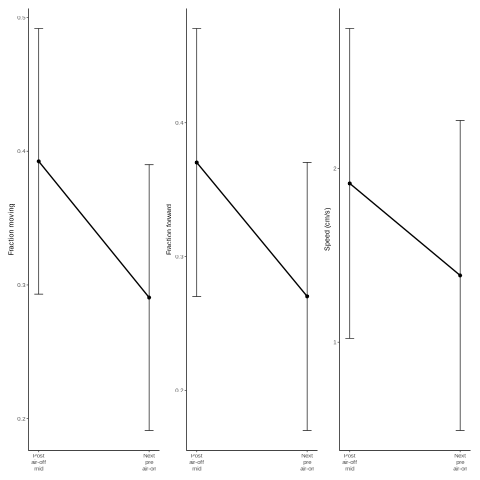

In [15]:
%%R -i air_next_pre_emm_df -i fig_dir_str

library(dplyr)
library(ggplot2)
library(patchwork)

out_dir <- fig_dir_str
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)

outcome_labels <- c(
  frac_moving = "Fraction moving",
  frac_forward = "Fraction forward",
  mean_speed_path_cms = "Speed (cm/s)"
)

comparison_labels <- c(
  post_air_off_mid = "Post\nair-off\nmid",
  next_pre_air_on = "Next\npre\nair-on"
)

theme_comp <- function() {
  theme_classic(base_size = 7) +
    theme(
      axis.title = element_text(size = 7),
      axis.text.x = element_text(size = 6),
      axis.text.y = element_text(size = 6),
      legend.position = "none",
      plot.title = element_blank(),
      plot.margin = margin(3, 4, 3, 3)
    )
}

plot_list <- list()

for (outcome in names(outcome_labels)) {

  dfp <- air_next_pre_emm_df %>%
    filter(outcome == !!outcome) %>%
    mutate(
      comparison_epoch = factor(
        comparison_epoch,
        levels = c("post_air_off_mid", "next_pre_air_on")
      ),
      x = as.numeric(comparison_epoch)
    )

  p <- ggplot(dfp, aes(x = x, y = emmean)) +
    geom_line(linewidth = 0.65) +
    geom_point(size = 1.2) +
    geom_errorbar(
      aes(ymin = lower.CL, ymax = upper.CL),
      width = 0.08,
      linewidth = 0.3
    ) +
    scale_x_continuous(
      breaks = c(1, 2),
      labels = unname(comparison_labels[c("post_air_off_mid", "next_pre_air_on")])
    ) +
    labs(
      x = NULL,
      y = outcome_labels[[outcome]]
    ) +
    theme_comp()

  plot_list[[outcome]] <- p
}

p_combined <- plot_list[["frac_moving"]] +
  plot_list[["frac_forward"]] +
  plot_list[["mean_speed_path_cms"]] +
  plot_layout(nrow = 1)

print(p_combined)

ggsave(
  filename = file.path(out_dir, "Fig_air_late_off_to_next_pre_air_on_3panel.pdf"),
  plot = p_combined,
  width = 5.5,
  height = 2.0
)

ggsave(
  filename = file.path(out_dir, "Fig_air_late_off_to_next_pre_air_on_3panel.png"),
  plot = p_combined,
  width = 5.5,
  height = 2.0,
  dpi = 600
)

                                     contrast    estimate          SE        df
1...1                    air_onset_transition  0.50084154 0.006876343 24681.805
2...2                early_air_on_progression  0.04866266 0.006875107 24681.468
3...3                   air_on_mid_transition  0.04542808 0.006874726 24680.503
4                     late_air_on_progression  0.09407585 0.006874672 24680.707
5                       air_offset_transition -0.04486425 0.006879888 24687.268
6                      early_air_off_recovery -0.51584960 0.006889615 24685.542
7                      air_off_mid_transition -0.02601606 0.006895093 24678.665
8                        air_onset_transition  0.40369916 0.007208572 24683.645
9                    early_air_on_progression  0.12094503 0.007207278 24683.180
10                      air_on_mid_transition  0.06060988 0.007206883 24682.274
11                    late_air_on_progression  0.10779695 0.007206825 24682.391
12                      air_offset_trans

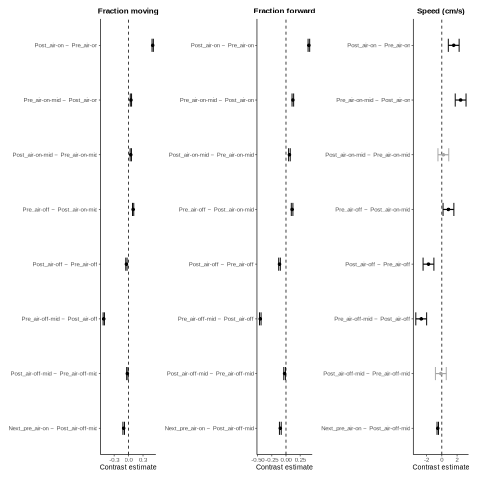

In [25]:
%%R -i air_cycle_contrasts_df -i fig_dir_str -i air_next_pre_contrasts_df

library(dplyr)
library(ggplot2)
library(patchwork)

# --------------------------------------------------
# Output folder
# --------------------------------------------------

out_dir <- fig_dir_str
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)

# --------------------------------------------------
# Combine main adjacent contrasts + next pre-air-on contrast
# --------------------------------------------------

main_contrasts_df <- air_cycle_contrasts_df %>%
  mutate(contrast_set = "air_cycle_adjacent")

next_pre_contrasts_df <- air_next_pre_contrasts_df %>%
  mutate(contrast_set = "late_air_off_to_next_pre_air_on")

contrast_plot_df <- bind_rows(
  main_contrasts_df,
  next_pre_contrasts_df
)

# --------------------------------------------------
# Keep only primary outcomes
# --------------------------------------------------

primary_outcomes <- c(
  "frac_moving",
  "frac_forward",
  "mean_speed_path_cms"
)

contrast_plot_df <- contrast_plot_df %>%
  filter(outcome %in% primary_outcomes)

# --------------------------------------------------
# Human-readable labels
# --------------------------------------------------
minus <- "\u2212"

contrast_labels <- c(
  air_onset_transition =
    paste0("Post_air-on ", minus, " Pre_air-on"),

  early_air_on_progression =
    paste0("Pre_air-on-mid ", minus, " Post_air-on"),

  air_on_mid_transition =
    paste0("Post_air-on-mid ", minus, " Pre_air-on-mid"),

  late_air_on_progression =
    paste0("Pre_air-off ", minus, " Post_air-on-mid"),

  air_offset_transition =
    paste0("Post_air-off ", minus, " Pre_air-off"),

  early_air_off_recovery =
    paste0("Pre_air-off-mid ", minus, " Post_air-off"),

  air_off_mid_transition =
    paste0("Post_air-off-mid ", minus, " Pre_air-off-mid"),

  next_pre_air_on_minus_post_air_off_mid =
    paste0("Next_pre_air-on ", minus, " Post_air-off-mid")
)

contrast_order <- c(
  "air_onset_transition",
  "early_air_on_progression",
  "air_on_mid_transition",
  "late_air_on_progression",
  "air_offset_transition",
  "early_air_off_recovery",
  "air_off_mid_transition",
  "next_pre_air_on_minus_post_air_off_mid"
)

outcome_labels <- c(
  frac_moving = "Fraction moving",
  frac_forward = "Fraction forward",
  mean_speed_path_cms = "Speed (cm/s)"
)

# --------------------------------------------------
# Prepare plotting dataframe
# --------------------------------------------------

contrast_plot_df <- contrast_plot_df %>%
  mutate(
    contrast = as.character(contrast),
    contrast_label = contrast_labels[contrast],
    contrast_label = factor(
      contrast_label,
      levels = rev(contrast_labels[contrast_order])
    ),
    outcome_label = outcome_labels[outcome],
    outcome_label = factor(
      outcome_label,
      levels = outcome_labels[primary_outcomes]
    )
  )

# --------------------------------------------------
# p-value labels, optional for table inspection
# --------------------------------------------------

contrast_plot_df <- contrast_plot_df %>%
  mutate(
    p_label = case_when(
      p.value < 0.001 ~ "p < 0.001",
      TRUE ~ paste0("p = ", sprintf("%.3f", p.value))
    ),
    sig_status = case_when(
      p.value < 0.05 ~ "Significant",
      TRUE ~ "Not significant"
    )
  )

# --------------------------------------------------
# Theme
# --------------------------------------------------

theme_contrast <- function() {
  theme_classic(base_size = 7) +
    theme(
      axis.title = element_text(size = 7),
      axis.text.x = element_text(size = 6),
      axis.text.y = element_text(size = 6),
      plot.title = element_text(size = 8, face = "bold", hjust = 0.5),
      plot.margin = margin(3, 6, 3, 3),
      legend.position = "none"
    )
}

# --------------------------------------------------
# Helper function for one outcome
# --------------------------------------------------

make_contrast_plot <- function(outcome_i) {

  dfp <- contrast_plot_df %>%
    filter(outcome == outcome_i) %>%
    mutate(
      contrast_y = as.numeric(contrast_label)
    )

  label_i <- unname(outcome_labels[outcome_i])

  p <- ggplot(dfp) +

    geom_vline(
      xintercept = 0,
      linetype = "dashed",
      linewidth = 0.35,
      colour = "black"
    ) +

    # 95% CI horizontal line
    geom_segment(
      aes(
        x = lower.CL,
        xend = upper.CL,
        y = contrast_y,
        yend = contrast_y,
        colour = sig_status
      ),
      linewidth = 0.55
    ) +

    # left CI cap
    geom_segment(
      aes(
        x = lower.CL,
        xend = lower.CL,
        y = contrast_y - 0.12,
        yend = contrast_y + 0.12,
        colour = sig_status
      ),
      linewidth = 0.45
    ) +

    # right CI cap
    geom_segment(
      aes(
        x = upper.CL,
        xend = upper.CL,
        y = contrast_y - 0.12,
        yend = contrast_y + 0.12,
        colour = sig_status
      ),
      linewidth = 0.45
    ) +

    # point estimate
    geom_point(
      aes(
        x = estimate,
        y = contrast_y,
        colour = sig_status
      ),
      size = 1.0
    ) +

    scale_y_continuous(
      breaks = dfp$contrast_y,
      labels = dfp$contrast_label
    ) +

    scale_colour_manual(
      values = c(
        "Significant" = "black",
        "Not significant" = "grey65"
      )
    ) +

    labs(
      title = label_i,
      x = "Contrast estimate",
      y = NULL
    ) +

    theme_contrast()

  return(p)
}

# --------------------------------------------------
# Make three panels
# --------------------------------------------------

p_frac_moving <- make_contrast_plot("frac_moving")
p_frac_forward <- make_contrast_plot("frac_forward")
p_speed <- make_contrast_plot("mean_speed_path_cms")

p_combined <- p_frac_moving +
  p_frac_forward +
  p_speed +
  plot_layout(nrow = 1)

print(p_combined)

# --------------------------------------------------
# Save figure
# --------------------------------------------------

ggsave(
  filename = file.path(out_dir, "Fig_air_cycle_planned_contrasts_3panel.pdf"),
  plot = p_combined,
  width = 7.2,
  height = 2.4,
  device = cairo_pdf
)

ggsave(
  filename = file.path(out_dir, "Fig_air_cycle_planned_contrasts_3panel.png"),
  plot = p_combined,
  width = 7.2,
  height = 2.4,
  dpi = 600
)

# --------------------------------------------------
# Save contrast table
# --------------------------------------------------

write.csv(
  contrast_plot_df,
  file.path(out_dir, "air_cycle_planned_contrasts_for_plot.csv"),
  row.names = FALSE
)

print(contrast_plot_df)

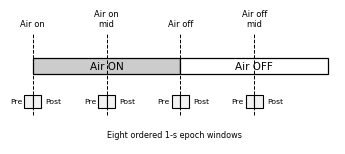

In [38]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# --------------------------------------------------
# Output folder
# --------------------------------------------------
try:
    fig_dir = Path(fig_dir_str)
except NameError:
    fig_dir = Path("figure_drafts")

fig_dir.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# Define one full air cycle schematically
# --------------------------------------------------
t_air_on = 0
t_air_off = 8
t_next_air_on = 16

t_air_on_mid = (t_air_on + t_air_off) / 2
t_air_off_mid = (t_air_off + t_next_air_on) / 2

anchors = [
    (t_air_on, "Air on"),
    (t_air_on_mid, "Air on\nmid"),
    (t_air_off, "Air off"),
    (t_air_off_mid, "Air off\nmid"),
]

timeline_start = -1.0
timeline_end = t_next_air_on + 0.4

# narrower epoch boxes
w = 0.45

def add_epoch_pair(ax, anchor_t, y, h, w):
    # pre
    ax.add_patch(Rectangle(
        (anchor_t - w, y), w, h,
        facecolor="0.95", edgecolor="black", linewidth=0.8
    ))
    ax.text(anchor_t - 2*w, y + h/2, "Pre",
            ha="center", va="center", fontsize=5.5)

    # post
    ax.add_patch(Rectangle(
        (anchor_t, y), w, h,
        facecolor="0.95", edgecolor="black", linewidth=0.8
    ))
    ax.text(anchor_t + 2.5*w, y + h/2, "Post",
            ha="center", va="center", fontsize=5.5)

# --------------------------------------------------
# Figure
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(3.3, 1.4))

bar_y = 0.60
bar_h = 0.12

# Air ON
ax.add_patch(Rectangle(
    (t_air_on, bar_y),
    t_air_off - t_air_on,
    bar_h,
    facecolor="0.80",
    edgecolor="black",
    linewidth=0.9
))

# Air OFF
ax.add_patch(Rectangle(
    (t_air_off, bar_y),
    t_next_air_on - t_air_off,
    bar_h,
    facecolor="white",
    edgecolor="black",
    linewidth=0.9
))

# Labels inside bars
ax.text((t_air_on + t_air_off)/2, bar_y + bar_h/2, "Air ON",
        ha="center", va="center", fontsize=7.5)
ax.text((t_air_off + t_next_air_on)/2, bar_y + bar_h/2, "Air OFF",
        ha="center", va="center", fontsize=7.5)

# Anchor lines and labels
for x, label in anchors:
    ax.plot([x, x], [0.28, 0.92], linestyle="--", color="black", linewidth=0.7)
    ax.text(x, 0.95, label, ha="center", va="bottom", fontsize=6)

# Pre/post boxes
box_y = 0.33
box_h = 0.10
for x, _ in anchors:
    add_epoch_pair(ax, x, box_y, box_h, w)

# Caption text
ax.text(
    (timeline_start + timeline_end)/2,
    0.12,
    "Eight ordered 1-s epoch windows",
    ha="center", va="center", fontsize=5.8
)

# Formatting
ax.set_xlim(timeline_start, timeline_end)
ax.set_ylim(0.05, 1.02)
ax.axis("off")

fig.tight_layout(pad=0.15)

fig.savefig(fig_dir / "Figure_air_cycle_panelA_schematic_compact.pdf", bbox_inches="tight")
fig.savefig(fig_dir / "Figure_air_cycle_panelA_schematic_compact.png", dpi=600, bbox_inches="tight")

plt.show()

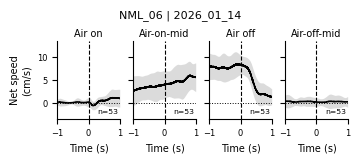

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


def plot_raw_net_speed_traces_air_cycle_4anchors_one_animal(
    epoch_matrix_df,
    animal,
    phase="air_training",
    date=None,
    # phase_day_number_good=1,
    speed_key="speed_net_cms",
    pre_s=1.0,
    post_s=1.0,
    max_traces=None,
    show_individual_traces=True,
    fig_dir=None,
    save_prefix="Fig_air_cycle_raw_net_speed_one_animal",
):
    """
    Plot raw net-speed traces around the 4 air-cycle anchors for one animal/day.

    Panels:
      1. air_on
      2. air_on_mid
      3. air_off
      4. air_off_mid

    Gray lines = individual events/trials
    Black line = mean
    Gray shaded region = mean ± SD

    Net speed:
      positive = forward direction
      negative = backward direction
    """

    # --------------------------------------------------
    # Anchor order and labels
    # --------------------------------------------------

    anchor_order = [
        "air_on",
        "air_on_mid",
        "air_off",
        "air_off_mid",
    ]

    anchor_labels = {
        "air_on": "Air on",
        "air_on_mid": "Air-on-mid",
        "air_off": "Air off",
        "air_off_mid": "Air-off-mid",
    }

    # --------------------------------------------------
    # Select all rows for this animal / phase / day
    # --------------------------------------------------

    sub_all = epoch_matrix_df[
        (epoch_matrix_df["animal"] == animal) &
        (epoch_matrix_df["phase"] == phase) &
        # (epoch_matrix_df["phase_day_number_good"] == phase_day_number_good) &
        (epoch_matrix_df["anchor_name"].isin(anchor_order))
    ].copy()

    if sub_all.empty:
        print(
            f"No rows found for animal={animal}, phase={phase}, "
            f"day={phase_day_number_good}, anchors={anchor_order}"
        )
        print("Available anchors for this animal/phase:")
        display(
            epoch_matrix_df[
                (epoch_matrix_df["animal"] == animal) &
                (epoch_matrix_df["phase"] == phase)
            ]["anchor_name"].value_counts()
        )
        return None

    # --------------------------------------------------
    # Get date
    # --------------------------------------------------

    # dates = sorted(sub_all["date"].dropna().unique())

    # if len(dates) == 0:
    #     print("No date found.")
    #     return None

    # if len(dates) > 1:
    #     print("More than one date found for this phase day. Using first:", dates[0])

    # date = dates[0]

    sub_all = sub_all[sub_all["date"] == date].copy()

    # --------------------------------------------------
    # Load raw speed data once
    # --------------------------------------------------

    b = pdio.load_behavior_h5(
        animal,
        date,
        keys=[speed_key, "fs"]
    )

    speed = np.asarray(b[speed_key]).reshape(-1)
    fs = float(np.asarray(b["fs"]).squeeze())

    n_pre = int(round(pre_s * fs))
    n_post = int(round(post_s * fs))
    expected_n = n_pre + n_post

    t = np.arange(-n_pre, n_post) / fs

    # --------------------------------------------------
    # Extract traces for each anchor
    # --------------------------------------------------

    traces_by_anchor = {}

    for anchor_name in anchor_order:

        sub = sub_all[sub_all["anchor_name"] == anchor_name].copy()

        if sub.empty:
            traces_by_anchor[anchor_name] = np.empty((0, expected_n))
            continue

        anchor_events = (
            sub[
                [
                    "animal",
                    "date",
                    "phase",
                    "event_number",
                    "anchor_name",
                    "anchor_time_s",
                ]
            ]
            .drop_duplicates()
            .sort_values("event_number")
            .reset_index(drop=True)
        )

        if max_traces is not None:
            anchor_events = anchor_events.iloc[:max_traces].copy()

        traces = []

        for _, ev in anchor_events.iterrows():

            anchor_time = ev["anchor_time_s"]

            if not np.isfinite(anchor_time):
                continue

            anchor_idx = int(round(anchor_time * fs))

            start_idx = anchor_idx - n_pre
            end_idx = anchor_idx + n_post

            if start_idx < 0:
                continue

            if end_idx > len(speed):
                continue

            trace = speed[start_idx:end_idx]

            if len(trace) == expected_n:
                traces.append(trace)

        if len(traces) > 0:
            traces_by_anchor[anchor_name] = np.vstack(traces)
        else:
            traces_by_anchor[anchor_name] = np.empty((0, expected_n))

    # --------------------------------------------------
    # Compute common y-limits
    # --------------------------------------------------

    all_valid_traces = [
        tr for tr in traces_by_anchor.values()
        if tr.shape[0] > 0
    ]

    if len(all_valid_traces) == 0:
        print("No valid traces extracted for any anchor.")
        return None

    all_traces = np.vstack(all_valid_traces)

    y_low, y_high = np.nanpercentile(all_traces, [1, 99])
    y_pad = 0.10 * (y_high - y_low)

    y_lim = (y_low - y_pad, y_high + y_pad)

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(3.5, 1.5),
        sharex=True,
        sharey=True
    )

    for ax, anchor_name in zip(axes, anchor_order):

        traces = traces_by_anchor[anchor_name]

        if traces.shape[0] == 0:
            ax.text(
                0.5,
                0.5,
                "No traces",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=7
            )
            ax.set_title(anchor_labels[anchor_name], fontsize=7)
            continue

        mean_trace = np.nanmean(traces, axis=0)
        std_trace = np.nanstd(traces, axis=0)

        if show_individual_traces:
            for tr in traces:
                ax.plot(
                    t,
                    tr,
                    color="0.75",
                    linewidth=0.35,
                    alpha=0.35
                )

        ax.fill_between(
            t,
            mean_trace - std_trace,
            mean_trace + std_trace,
            color="0.80",
            alpha=0.7,
            linewidth=0
        )

        ax.plot(
            t,
            mean_trace,
            color="black",
            linewidth=1.2
        )

        ax.axvline(
            0,
            color="black",
            linestyle="--",
            linewidth=0.8
        )

        ax.axhline(
            0,
            color="black",
            linestyle=":",
            linewidth=0.7
        )

        ax.set_title(anchor_labels[anchor_name], fontsize=7, pad=3)

        ax.text(
            0.97,
            0.05,
            f"n={traces.shape[0]}",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=5.5
        )

        ax.set_xlim(-pre_s, post_s)
        ax.set_ylim(y_lim)

        ax.tick_params(axis="both", labelsize=6)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel("Net speed\n(cm/s)", fontsize=7)

    for ax in axes:
        ax.set_xlabel("Time (s)", fontsize=7)

    fig.suptitle(
        f"{animal} | {date}",
        fontsize=8,
        y=0.99
    )

    fig.tight_layout(pad=0.35)

    # --------------------------------------------------
    # Save
    # --------------------------------------------------

    if fig_dir is not None:
        fig_dir = Path(fig_dir)
        fig_dir.mkdir(parents=True, exist_ok=True)

        fname_base = (
            f"{save_prefix}_{animal}_{phase}_{date}"
        )

        fig.savefig(
            fig_dir / f"{fname_base}.pdf",
            bbox_inches="tight"
        )

        fig.savefig(
            fig_dir / f"{fname_base}.png",
            dpi=600,
            bbox_inches="tight"
        )

    plt.show()

    return {
        "fig": fig,
        "axes": axes,
        "traces_by_anchor": traces_by_anchor,
        "time": t,
        "animal": animal,
        "date": date,
        "phase": phase,
        # "phase_day_number_good": phase_day_number_good,
        "speed_key": speed_key,
    }

out = plot_raw_net_speed_traces_air_cycle_4anchors_one_animal(
    epoch_matrix_df=encoder_epoch_df,
    animal="NML_06",
    phase="air_training",
    date = "2026_01_14",
    # phase_day_number_good=1,
    speed_key="speed_net_cms",
    pre_s=1.0,
    post_s=1.0,
    max_traces=None,
    show_individual_traces=False,
    fig_dir=fig_dir_str,
)

,animal,n_sessions_air_on,n_sessions_air_on_mid,n_sessions_air_off,n_sessions_air_off_mid
0,NML_04,15,15,15,15
1,NML_05,15,15,15,15
2,NML_06,15,15,15,15
3,NML_07,16,16,16,16
4,NML_08,17,17,17,17


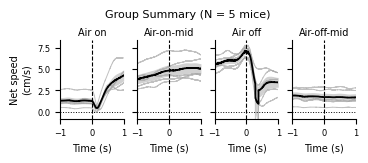

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def detect_anchor_order_for_phase(epoch_matrix_df, phase):
    available = sorted(
        epoch_matrix_df.loc[
            epoch_matrix_df["phase"].astype(str) == str(phase),
            "anchor_name"
        ].dropna().unique()
    )

    candidate_orders = [
        ["led_on", "led_on_mid", "led_off", "led_off_mid"],
        ["LED_on", "LED_on_mid", "LED_off", "LED_off_mid"],
        ["air_on", "air_on_mid", "air_off", "air_off_mid"],
        ["air_onset", "air_on_mid", "air_offset", "air_off_mid"],
    ]

    for cand in candidate_orders:
        if all(a in available for a in cand):
            return cand

    print("Available anchors:")
    print(available)
    raise ValueError("Could not detect the four anchor names automatically.")


def plot_group_raw_net_speed_around_4anchors(
    epoch_matrix_df,
    phase="air_training",
    animals=None,
    speed_key="speed_net_cms",
    pre_s=1.0,
    post_s=1.0,
    max_session_time_min=20,
    max_traces_per_session_anchor=None,
    show_individual_animals=True,
    fig_dir=None,
    save_prefix="Fig_group_raw_net_speed_4anchors",
):
    """
    Group raw net-speed traces around the four timing anchors.

    Averaging hierarchy:
      event traces -> session mean -> animal mean -> group mean ± SEM

    This avoids treating event windows as independent animals.
    """

    # --------------------------------------------------
    # Output folder
    # --------------------------------------------------

    if fig_dir is not None:
        fig_dir = Path(fig_dir)
        fig_dir.mkdir(parents=True, exist_ok=True)

    # --------------------------------------------------
    # Anchor setup
    # --------------------------------------------------

    anchor_order = detect_anchor_order_for_phase(epoch_matrix_df, phase)

    anchor_labels = {
        anchor_order[0]: "LED on" if "led" in anchor_order[0].lower() else "Air on",
        anchor_order[1]: "LED-on-mid" if "led" in anchor_order[1].lower() else "Air-on-mid",
        anchor_order[2]: "LED off" if "led" in anchor_order[2].lower() else "Air off",
        anchor_order[3]: "LED-off-mid" if "led" in anchor_order[3].lower() else "Air-off-mid",
    }

    # --------------------------------------------------
    # Filter dataframe
    # --------------------------------------------------

    df = epoch_matrix_df[
        (epoch_matrix_df["phase"].astype(str) == str(phase)) &
        (epoch_matrix_df["anchor_name"].isin(anchor_order))
    ].copy()

    if animals is None:
        animals = sorted(df["animal"].dropna().unique())
    else:
        animals = list(animals)
        df = df[df["animal"].isin(animals)].copy()

    if max_session_time_min is not None:
        df = df[df["anchor_time_s"] <= max_session_time_min * 60].copy()

    if df.empty:
        raise ValueError("No rows left after filtering.")

    # --------------------------------------------------
    # Sampling settings
    # --------------------------------------------------

    animal_mean_traces = {a: [] for a in anchor_order}
    animal_ids_used = {a: [] for a in anchor_order}
    session_counts = []

    # --------------------------------------------------
    # Extract traces animal by animal
    # --------------------------------------------------

    for animal in animals:

        df_animal = df[df["animal"] == animal].copy()

        if df_animal.empty:
            continue

        # session-level means for this animal
        session_mean_by_anchor = {a: [] for a in anchor_order}

        for date, df_session in df_animal.groupby("date", observed=True):

            # Load raw behavior once per session
            try:
                b = pdio.load_behavior_h5(
                    animal,
                    date,
                    keys=[speed_key, "fs"]
                )
            except Exception as e:
                print(f"Skipping {animal} {date}: could not load H5. Error: {e}")
                continue

            speed = np.asarray(b[speed_key]).reshape(-1)
            fs = float(np.asarray(b["fs"]).squeeze())

            n_pre = int(round(pre_s * fs))
            n_post = int(round(post_s * fs))
            expected_n = n_pre + n_post
            rel_t = np.arange(-n_pre, n_post) / fs

            for anchor_name in anchor_order:

                sub = df_session[df_session["anchor_name"] == anchor_name].copy()

                if sub.empty:
                    continue

                anchor_events = (
                    sub[
                        [
                            "event_number",
                            "anchor_name",
                            "anchor_time_s",
                        ]
                    ]
                    .drop_duplicates()
                    .sort_values("event_number")
                    .reset_index(drop=True)
                )

                if max_traces_per_session_anchor is not None:
                    anchor_events = anchor_events.iloc[:max_traces_per_session_anchor].copy()

                traces = []

                for _, ev in anchor_events.iterrows():

                    anchor_time = ev["anchor_time_s"]

                    if not np.isfinite(anchor_time):
                        continue

                    anchor_idx = int(round(anchor_time * fs))
                    start_idx = anchor_idx - n_pre
                    end_idx = anchor_idx + n_post

                    if start_idx < 0 or end_idx > len(speed):
                        continue

                    trace = speed[start_idx:end_idx]

                    if len(trace) == expected_n:
                        traces.append(trace)

                if len(traces) > 0:
                    traces = np.vstack(traces)
                    session_mean = np.nanmean(traces, axis=0)
                    session_mean_by_anchor[anchor_name].append(session_mean)

        # Average session means within animal
        for anchor_name in anchor_order:

            if len(session_mean_by_anchor[anchor_name]) == 0:
                continue

            session_means = np.vstack(session_mean_by_anchor[anchor_name])
            animal_mean = np.nanmean(session_means, axis=0)

            animal_mean_traces[anchor_name].append(animal_mean)
            animal_ids_used[anchor_name].append(animal)

        session_counts.append({
            "animal": animal,
            **{
                f"n_sessions_{anchor_name}": len(session_mean_by_anchor[anchor_name])
                for anchor_name in anchor_order
            }
        })

    session_counts_df = pd.DataFrame(session_counts)
    display(session_counts_df)

    # --------------------------------------------------
    # Convert to arrays and compute group mean ± SEM
    # --------------------------------------------------

    group_summary = {}

    for anchor_name in anchor_order:

        if len(animal_mean_traces[anchor_name]) == 0:
            group_summary[anchor_name] = None
            continue

        arr = np.vstack(animal_mean_traces[anchor_name])

        group_mean = np.nanmean(arr, axis=0)
        group_sem = np.nanstd(arr, axis=0, ddof=1) / np.sqrt(arr.shape[0])

        group_summary[anchor_name] = {
            "animal_mean_traces": arr,
            "group_mean": group_mean,
            "group_sem": group_sem,
            "n_animals": arr.shape[0],
            "animal_ids": animal_ids_used[anchor_name],
        }

    # --------------------------------------------------
    # Common y-limits
    # --------------------------------------------------

    all_group_values = []

    for anchor_name in anchor_order:
        s = group_summary[anchor_name]
        if s is None:
            continue
        all_group_values.append(s["animal_mean_traces"])

    all_group_values = np.vstack(all_group_values)

    y_low, y_high = np.nanpercentile(all_group_values, [1, 99])
    y_pad = 0.15 * (y_high - y_low)
    y_lim = (y_low - y_pad, y_high + y_pad)

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(3.5, 1.5),
        sharex=True,
        sharey=True
    )

    for ax, anchor_name in zip(axes, anchor_order):

        s = group_summary[anchor_name]

        if s is None:
            ax.text(
                0.5,
                0.5,
                "No data",
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=7
            )
            continue

        animal_arr = s["animal_mean_traces"]
        group_mean = s["group_mean"]
        group_sem = s["group_sem"]

        if show_individual_animals:
            for tr in animal_arr:
                ax.plot(
                    rel_t,
                    tr,
                    color="0.65",
                    linewidth=0.7,
                    alpha=0.7
                )

        ax.fill_between(
            rel_t,
            group_mean - group_sem,
            group_mean + group_sem,
            color="0.80",
            linewidth=0,
            alpha=0.9
        )

        ax.plot(
            rel_t,
            group_mean,
            color="black",
            linewidth=1.3
        )

        ax.axvline(0, linestyle="--", linewidth=0.8, color="black")
        ax.axhline(0, linestyle=":", linewidth=0.7, color="black")

        ax.set_title(anchor_labels[anchor_name], fontsize=7, pad=3)
        ax.set_xlabel("Time (s)", fontsize=7)
        ax.tick_params(axis="both", labelsize=6)
        ax.set_xlim(-pre_s, post_s)
        ax.set_ylim(y_lim)

        # ax.text(
        #     0.96,
        #     0.02,
        #     f"N={s['n_animals']}",
        #     transform=ax.transAxes,
        #     ha="right",
        #     va="bottom",
        #     fontsize=5.5
        # )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel("Net speed\n(cm/s)", fontsize=7)

    fig.suptitle(
        f"Group Summary (N = 5 mice)",
        fontsize=8,
        y=0.99
    )

    fig.tight_layout(pad=0.35)

    # --------------------------------------------------
    # Save
    # --------------------------------------------------

    if fig_dir is not None:
        fname = f"{save_prefix}_{phase}"

        fig.savefig(
            fig_dir / f"{fname}.pdf",
            bbox_inches="tight"
        )

        # fig.savefig(
        #     fig_dir / f"{fname}.png",
        #     dpi=600,
        #     bbox_inches="tight"
        # )

    plt.show()

    return {
        "fig": fig,
        "axes": axes,
        "rel_t": rel_t,
        "group_summary": group_summary,
        "session_counts_df": session_counts_df,
        "anchor_order": anchor_order,
    }

out_group = plot_group_raw_net_speed_around_4anchors(
    epoch_matrix_df=encoder_epoch_df,
    phase="air_training",
    animals=None,                    # or ["NML_04", "NML_05", ...]
    speed_key="speed_net_cms",
    pre_s=1.0,
    post_s=1.0,
    max_session_time_min=20,
    show_individual_animals=True,
    fig_dir=fig_dir_str,
)

In [ ]:
import pandas as pd

df_names = [
    name for name, obj in globals().items()
    if isinstance(obj, pd.DataFrame)
]

for name in df_names:
    if any(key in name.lower() for key in ["air", "epoch", "trend", "slope"]):
        print(name, globals()[name].shape)
        print(list(globals()[name].columns)[:20])
        print()

encoder_epoch_df (101861, 59)
['animal', 'date', 'phase', 'event_number', 'anchor_name', 'anchor_type', 'anchor_time_s', 'window_position', 'window_s', 'epoch_name', 'window_start_s', 'window_end_s', 'start_idx', 'end_idx', 'on_time_s', 'off_time_s', 'next_on_time_s', 'on_duration_s', 'off_duration_s', 'session_duration_s']

air_cycle_df (42362, 12)
['animal', 'date', 'animal_day', 'air_cycle_id', 'epoch_name', 'phase_session', 'phase_session_c', 'session_time_min', 'session_time_10m_c', 'frac_moving', 'frac_forward', 'mean_speed_path_cms']

air_cycle_stats_df (72, 8)
['outcome', 'term', 'beta', 'se', 'df', 't', 'p', 'n_obs']

air_cycle_contrasts_df (21, 9)
['contrast', 'estimate', 'SE', 'df', 'lower.CL', 'upper.CL', 't.ratio', 'p.value', 'outcome']

air_cycle_emm_df (24, 9)
['epoch_name', 'emmean', 'SE', 'df', 'lower.CL', 'upper.CL', 't.ratio', 'p.value', 'outcome']

air_cycle_r2_df (3, 3)
['outcome', 'marginal_R2', 'conditional_R2']

air_next_pre_df (6916, 13)
['animal', 'date', 'ani

In [81]:
%%R -i epoch_df -o air_epoch_trends_df -o air_epoch_model_info_df

library(lme4)
library(lmerTest)
library(dplyr)
library(emmeans)

# --------------------------------------------------
# Prepare data
# --------------------------------------------------

epoch_df$animal <- factor(epoch_df$animal)
epoch_df$animal_day <- factor(epoch_df$animal_day)
epoch_df$air_cycle_id <- factor(epoch_df$air_cycle_id)

epoch_order <- c(
  "air_on_pre_1s",
  "air_on_post_1s",
  "air_on_mid_pre_1s",
  "air_on_mid_post_1s",
  "air_off_pre_1s",
  "air_off_post_1s",
  "air_off_mid_pre_1s",
  "air_off_mid_post_1s"
)

epoch_order <- epoch_order[epoch_order %in% unique(epoch_df$epoch_name)]

epoch_df$epoch_name <- factor(
  epoch_df$epoch_name,
  levels = epoch_order
)

primary_outcomes <- c(
  "frac_moving",
  "frac_forward",
  "mean_speed_path_cms"
)

primary_outcomes <- primary_outcomes[primary_outcomes %in% names(epoch_df)]

emm_options(
  lmer.df = "satterthwaite",
  lmerTest.limit = nrow(epoch_df) + 1000,
  pbkrtest.limit = nrow(epoch_df) + 1000
)

# --------------------------------------------------
# Fit models and extract epoch-specific slopes
# --------------------------------------------------

trend_list <- list()
model_info_list <- list()

for (outcome in primary_outcomes) {

  cat("\n\n==============================\n")
  cat("Fitting air-cycle epoch trend model for:", outcome, "\n")
  cat("==============================\n")

  df_i <- epoch_df %>%
    filter(
      !is.na(.data[[outcome]]),
      !is.na(epoch_name),
      !is.na(phase_session_c),
      !is.na(session_time_10m_c),
      !is.na(animal),
      !is.na(animal_day),
      !is.na(air_cycle_id)
    )

  formula_text <- paste0(
    outcome,
    " ~ epoch_name * phase_session_c + ",
    "epoch_name * session_time_10m_c + ",
    "(1 | animal) + (1 | animal_day) + (1 | air_cycle_id)"
  )

  m <- lmer(
    as.formula(formula_text),
    data = df_i,
    REML = FALSE,
    control = lmerControl(
      optimizer = "bobyqa",
      optCtrl = list(maxfun = 2e5)
    )
  )

  singular_flag <- isSingular(m, tol = 1e-4)

  model_info_list[[outcome]] <- data.frame(
    outcome = outcome,
    n_obs = nobs(m),
    is_singular = singular_flag,
    logLik = as.numeric(logLik(m)),
    AIC = AIC(m),
    BIC = BIC(m),
    row.names = NULL
  )

  # --------------------------------------------------
  # D: exposure-session slope for each epoch
  # estimated at mean within-session time
  # --------------------------------------------------

  exp_trends <- emtrends(
    m,
    ~ epoch_name,
    var = "phase_session_c",
    at = list(session_time_10m_c = 0),
    lmer.df = "satterthwaite"
  )

  exp_df <- as.data.frame(
    summary(exp_trends, infer = c(TRUE, TRUE), null = 0)
  )

  exp_df <- exp_df %>%
    mutate(
      outcome = outcome,
      trend_type = "Exposure-session trend",
      beta = phase_session_c.trend,
      beta_label = "beta/session",
      singular_fit = singular_flag
    ) %>%
    select(
      outcome, trend_type, epoch_name,
      beta, SE, df, lower.CL, upper.CL, t.ratio, p.value,
      beta_label, singular_fit
    )

  # --------------------------------------------------
  # E: within-session-time slope for each epoch
  # estimated at mean exposure session
  # --------------------------------------------------

  time_trends <- emtrends(
    m,
    ~ epoch_name,
    var = "session_time_10m_c",
    at = list(phase_session_c = 0),
    lmer.df = "satterthwaite"
  )

  time_df <- as.data.frame(
    summary(time_trends, infer = c(TRUE, TRUE), null = 0)
  )

  time_df <- time_df %>%
    mutate(
      outcome = outcome,
      trend_type = "Within-session-time trend",
      beta = session_time_10m_c.trend,
      beta_label = "beta/10 min",
      singular_fit = singular_flag
    ) %>%
    select(
      outcome, trend_type, epoch_name,
      beta, SE, df, lower.CL, upper.CL, t.ratio, p.value,
      beta_label, singular_fit
    )

  trend_list[[outcome]] <- bind_rows(exp_df, time_df)
}

air_epoch_trends_df <- bind_rows(trend_list)
air_epoch_model_info_df <- bind_rows(model_info_list)

cat("\n\n===== Model info =====\n")
print(air_epoch_model_info_df)

cat("\n\n===== Epoch-specific trends =====\n")
print(air_epoch_trends_df)



Fitting air-cycle epoch trend model for: frac_moving 


Fitting air-cycle epoch trend model for: frac_forward 


Fitting air-cycle epoch trend model for: mean_speed_path_cms 


===== Model info =====
              outcome n_obs is_singular     logLik       AIC       BIC
1         frac_moving 28229       FALSE   -5620.60  11297.20  11528.15
2        frac_forward 28229       FALSE   -6839.36  13734.72  13965.67
3 mean_speed_path_cms 28229       FALSE -116908.55 233873.09 234104.04


===== Epoch-specific trends =====
               outcome                trend_type          epoch_name
1          frac_moving    Exposure-session trend       air_on_pre_1s
2          frac_moving    Exposure-session trend      air_on_post_1s
3          frac_moving    Exposure-session trend   air_on_mid_pre_1s
4          frac_moving    Exposure-session trend  air_on_mid_post_1s
5          frac_moving    Exposure-session trend      air_off_pre_1s
6          frac_moving    Exposure-session trend     air_off_pos

,outcome,trend_type,epoch_name,beta,SE,df,lower.CL,upper.CL,t.ratio,p.value,beta_label,singular_fit
0,frac_moving,Exposure-session trend,air_on_pre_1s,-0.020904,0.002053,116.505180,-0.024970,-0.016838,-10.182258,8.395220e-18,beta/session,False
1,frac_moving,Exposure-session trend,air_on_post_1s,-0.000014,0.002053,116.462915,-0.004080,0.004051,-0.007019,9.944119e-01,beta/session,False
2,frac_moving,Exposure-session trend,air_on_mid_pre_1s,0.002771,0.002053,116.411636,-0.001295,0.006836,1.349809,1.796962e-01,beta/session,False
3,frac_moving,Exposure-session trend,air_on_mid_post_1s,-0.000167,0.002053,116.414224,-0.004233,0.003898,-0.081601,9.351039e-01,beta/session,False
4,frac_moving,Exposure-session trend,air_off_pre_1s,-0.001504,0.002052,116.361961,-0.005568,0.002561,-0.732596,4.652778e-01,beta/session,False
5,frac_moving,Exposure-session trend,air_off_post_1s,-0.003867,0.002053,116.522708,-0.007933,0.000199,-1.883454,6.213177e-02,beta/session,False
6,frac_moving,Exposure-session trend,air_off_mid_pre_1s,-0.023221,0.002054,116.606321,-0.027288,-0.019154,-11.307728,1.821090e-20,beta/session,False
7,frac_moving,Exposure-session trend,air_off_mid_post_1s,-0.024313,0.002054,116.606385,-0.028380,-0.020246,-11.839765,1.015929e-21,beta/session,False
8,frac_forward,Exposure-session trend,air_on_pre_1s,-0.020599,0.002154,115.265778,-0.024865,-0.016333,-9.564307,2.627803e-16,beta/session,False
9,frac_forward,Exposure-session trend,air_on_post_1s,0.006896,0.002154,115.224305,0.002631,0.011162,3.202339,1.762491e-03,beta/session,False


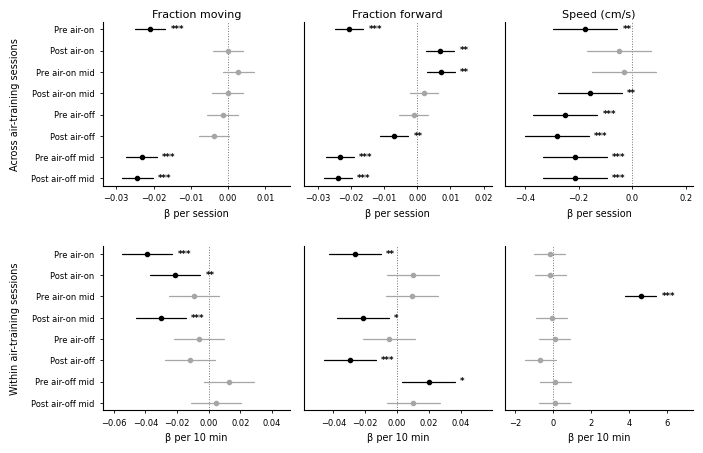

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ==================================================
# Source dataframe
# ==================================================

plot_df = air_epoch_trends_df.copy()

# --------------------------------------------------
# Orders and labels
# --------------------------------------------------

outcome_order = [
    "frac_moving",
    "frac_forward",
    "mean_speed_path_cms",
]

outcome_labels = {
    "frac_moving": "Fraction moving",
    "frac_forward": "Fraction forward",
    "mean_speed_path_cms": "Speed (cm/s)",
}

trend_order = [
    "Exposure-session trend",
    "Within-session-time trend",
]

trend_panel_labels = {
    "Exposure-session trend": "Across air-training sessions",
    "Within-session-time trend": "Within air-training sessions",
}

xaxis_labels = {
    "Exposure-session trend": "β per session",
    "Within-session-time trend": "β per 10 min",
}

epoch_order = [
    "air_on_pre_1s",
    "air_on_post_1s",
    "air_on_mid_pre_1s",
    "air_on_mid_post_1s",
    "air_off_pre_1s",
    "air_off_post_1s",
    "air_off_mid_pre_1s",
    "air_off_mid_post_1s",
    "next_air_on_pre_1s",
]

epoch_labels = {
    "air_on_pre_1s": "Pre air-on",
    "air_on_post_1s": "Post air-on",
    "air_on_mid_pre_1s": "Pre air-on mid",
    "air_on_mid_post_1s": "Post air-on mid",
    "air_off_pre_1s": "Pre air-off",
    "air_off_post_1s": "Post air-off",
    "air_off_mid_pre_1s": "Pre air-off mid",
    "air_off_mid_post_1s": "Post air-off mid",
    "next_air_on_pre_1s": "Next pre air-on",
}

# Keep only epochs present
epoch_order = [e for e in epoch_order if e in plot_df["epoch_name"].astype(str).unique()]

plot_df["outcome"] = pd.Categorical(
    plot_df["outcome"],
    categories=outcome_order,
    ordered=True
)

plot_df["trend_type"] = pd.Categorical(
    plot_df["trend_type"],
    categories=trend_order,
    ordered=True
)

plot_df["epoch_name"] = pd.Categorical(
    plot_df["epoch_name"],
    categories=epoch_order,
    ordered=True
)

plot_df["p.value"] = pd.to_numeric(plot_df["p.value"], errors="coerce")

plot_df = plot_df.sort_values(
    ["trend_type", "outcome", "epoch_name"]
).reset_index(drop=True)

display(plot_df)

# ==================================================
# Helper
# ==================================================

def p_to_stars(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""

# ==================================================
# Plot
# ==================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(7.0, 4.5),
    sharey=True
)

y_pos = np.arange(len(epoch_order))[::-1]

for row_i, trend_type in enumerate(trend_order):
    for col_i, outcome in enumerate(outcome_order):

        ax = axes[row_i, col_i]

        sub = plot_df[
            (plot_df["trend_type"] == trend_type) &
            (plot_df["outcome"] == outcome)
        ].copy()

        sub = (
            sub.set_index("epoch_name")
            .reindex(epoch_order)
            .reset_index()
        )

        beta = sub["beta"].astype(float).to_numpy()
        lo = sub["lower.CL"].astype(float).to_numpy()
        hi = sub["upper.CL"].astype(float).to_numpy()
        pvals = sub["p.value"].astype(float).to_numpy()

        sig = pvals < 0.05

        # CI lines
        for i in range(len(epoch_order)):
            color_i = "black" if sig[i] else "0.65"

            ax.plot(
                [lo[i], hi[i]],
                [y_pos[i], y_pos[i]],
                color=color_i,
                linewidth=0.9,
                solid_capstyle="round",
                zorder=2
            )

            ax.plot(
                beta[i],
                y_pos[i],
                marker="o",
                markersize=3.0,
                color=color_i,
                zorder=3
            )

            stars = p_to_stars(pvals[i])
            if stars:
                x_star = hi[i] + 0.04 * (np.nanmax(hi) - np.nanmin(lo))
                ax.text(
                    x_star,
                    y_pos[i],
                    stars,
                    va="center",
                    ha="left",
                    fontsize=6.2,
                    fontweight="bold"
                )

        ax.axvline(
            0,
            color="0.45",
            linewidth=0.7,
            linestyle=":",
            zorder=1
        )

        if row_i == 0:
            ax.set_title(
                outcome_labels[outcome],
                fontsize=8,
                pad=3
            )

        if col_i == 0:
            ax.set_yticks(y_pos)
            ax.set_yticklabels(
                [epoch_labels.get(e, e) for e in epoch_order],
                fontsize=6
            )
            ax.set_ylabel(
                trend_panel_labels[trend_type],
                fontsize=7,
                labelpad=8
            )
        else:
            ax.tick_params(axis="y", left=False, labelleft=False)

        ax.set_xlabel(
            xaxis_labels[trend_type],
            fontsize=7
        )

        ax.tick_params(
            axis="both",
            width=0.6,
            length=2.3,
            labelsize=6
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # x-axis padding
        x_min = np.nanmin(lo)
        x_max = np.nanmax(hi)
        x_rng = x_max - x_min if x_max > x_min else 1

        ax.set_xlim(
            x_min - 0.15 * x_rng,
            x_max + 0.28 * x_rng
        )

fig.tight_layout(pad=0.6, w_pad=0.8, h_pad=2)

# ==================================================
# Save
# ==================================================

try:
    fig_dir = Path(fig_dir_str)
except NameError:
    fig_dir = Path("figure_drafts")

fig_dir.mkdir(parents=True, exist_ok=True)

fig.savefig(
    fig_dir / "Fig_air_training_panelD_E_epoch_trends.pdf",
    bbox_inches="tight"
)

# fig.savefig(
#     fig_dir / "Fig_air_training_panelD_E_epoch_trends.png",
#     dpi=600,
#     bbox_inches="tight"
# )

plt.show()